![iSA logo](../iSA_logo.png)
### Materiały do zajęć Statystyka
#### Kurs Junior Data Scientist

**Wojciech Artichowicz**

W zeszycie przedstawiono podstawy statystyki opisowej dla analizy dwóch zmiennych losowych i regresji. W zeszycie przedstawiono dość **kłopotliwe dane**

In [1]:
import numpy as np
import scipy as sp
import scipy.stats as ssp
%matplotlib inline
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

In [2]:
N1 = 100
N2 = 100
X = ssp.norm(0,0.1)
Y = ssp.norm(10,0.1)
p = np.concatenate([X.rvs((N1,2)),Y.rvs((N2,2))])
print(p)
x = p[:,0]
y = p[:,1]

[[-6.33119457e-02 -1.33787758e-01]
 [-2.06187699e-01 -1.88664620e-01]
 [-7.02455343e-02 -1.37636862e-01]
 [ 1.09983113e-01  1.82683742e-01]
 [ 9.96152074e-02  1.02508548e-01]
 [ 1.19618853e-01  1.12018231e-01]
 [-1.38191404e-02 -5.03355693e-02]
 [-1.59896079e-01  5.61755565e-02]
 [ 1.62468633e-01  1.07345349e-01]
 [-2.46419899e-01 -7.04192715e-02]
 [ 4.86186437e-02 -1.40434351e-02]
 [-5.64517514e-02 -6.05399667e-02]
 [-4.31254700e-02  9.94830511e-03]
 [-2.15149087e-01 -8.74191380e-03]
 [-1.86582206e-01 -1.27582791e-02]
 [-5.81607140e-02 -1.50077475e-02]
 [-8.17114089e-02  3.47868382e-02]
 [-3.15191673e-02  1.21359748e-01]
 [-2.38627339e-02 -7.07193951e-02]
 [ 1.91880458e-01  2.34612561e-01]
 [-2.27595359e-02 -9.19509490e-02]
 [ 3.56427783e-02  5.99791123e-02]
 [-1.06127523e-01  1.23906938e-01]
 [ 1.37822307e-01 -1.66818324e-03]
 [-7.24959530e-02  6.16265206e-02]
 [-1.52276520e-01  1.59967424e-02]
 [-5.22315921e-02  4.46550253e-02]
 [-4.11789220e-02 -4.84322310e-03]
 [ 1.56771073e-01 -2

**Wykres rozrzutu**

Zwróć uwagę, że dane składają się z dwóch grup punktów bardzo mocno od siebie oddalonych. Jak sądzisz? Czy współczynniki korelacji i regresji liniowej wykażą silną liniową zależność?

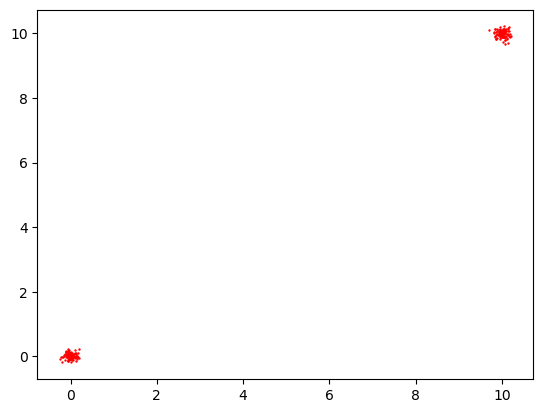

In [3]:
plt.scatter(x,y,marker="o",s=0.5,c="red",label="data")
pass

**Regresja liniowa zbioru danych - WSPANIAŁA PUŁAPKA**

Model wykazuje bardzo silną zależność liniową między zmiennymi X i Y. Jednak w tym przypadku model predykcyjny jest bezużyteczny a stosowanie regresji jest niepoprawne. Silna **pozorna** zależność liniowa wynika z faktu, że średnio dużym zmianom wartości $x$ towarzyszą duże zmiany wartości $y$, jednak w żadnym wypadku nie jest to zależność, którą można odzwierciedlić jako liniową.

LinregressResult(slope=0.9956761068663634, intercept=0.024636600645867368, rvalue=0.9996199940839633, pvalue=8.8362409620437e-311, stderr=0.001951279448645194, intercept_stderr=0.013807235355159856)


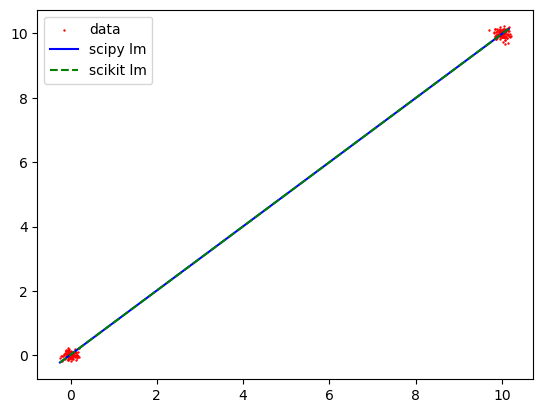

In [4]:
scipy_lm = ssp.linregress(x,y)
print(scipy_lm)
a= scipy_lm.slope
b = scipy_lm.intercept
xp = np.arange(min(x),max(x),0.1)
yp = a*xp+b
plt.scatter(x,y,marker="o",s=0.5,c="red",label="data")
plt.plot(xp,yp,c="blue",label="scipy lm")

LM = LinearRegression().fit(x.reshape((len(x),1)),y.reshape((len(x),1)))
yp1 = LM.predict(xp.reshape((len(xp),1)))
plt.plot(xp,yp1,c="green",linestyle = "--",label="scikit lm")
plt.legend()
pass

In [5]:
print([LM.coef_, LM.intercept_])

[array([[0.99567611]]), array([0.0246366])]


**Analiza dwuwymiarowego zbioru danych**

W przypadku analizy zmiennych wielowymiarowych wygodnie jest posłużyć się bibliotekami pandas oraz sns

In [6]:
import seaborn as sns
import pandas as pd

**Wykres rozrzutu i histogramy rozkładów brzegowych**

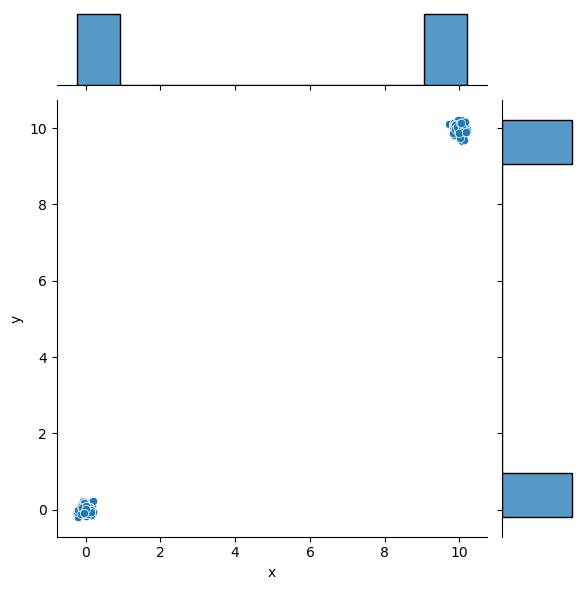

In [7]:
sns.jointplot(x="x", y="y", data=pd.DataFrame({"x":x,"y":y}));

**Wykres gęstościowy i jądrowe estymatory rozkładów brzegowych**

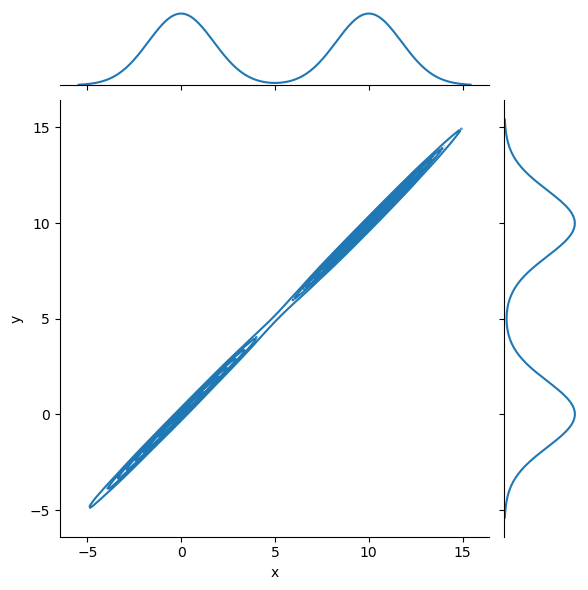

In [8]:
sns.jointplot(x="x", y="y", data=pd.DataFrame({"x":x,"y":y}), kind="kde");

**Wykres gęstościowy i jądrowe estymatory rozkładów brzegowych + wykres rozrzutu**

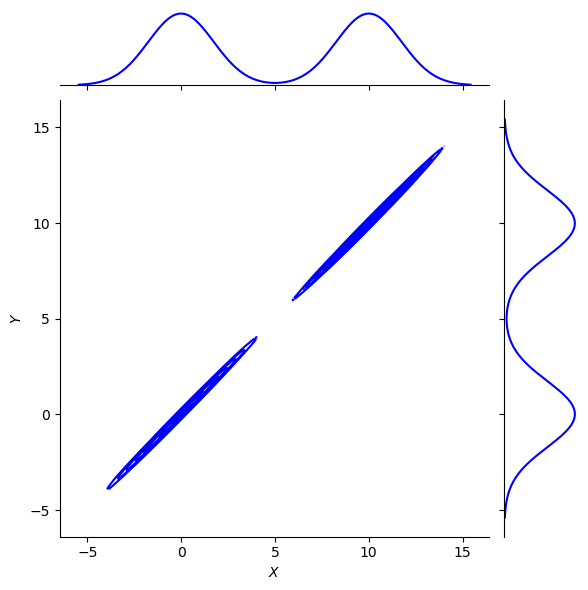

In [9]:
g = sns.jointplot(x="x", y="y", data=pd.DataFrame({"x":x,"y":y}), kind="kde", color="b")
g.plot_joint(plt.scatter, c="w", s=30, linewidth=1, marker="+")
g.ax_joint.collections[0].set_alpha(0)
g.set_axis_labels("$X$", "$Y$");

**Histogramy oraz wykresy rozrzutu tzw. pairplot**

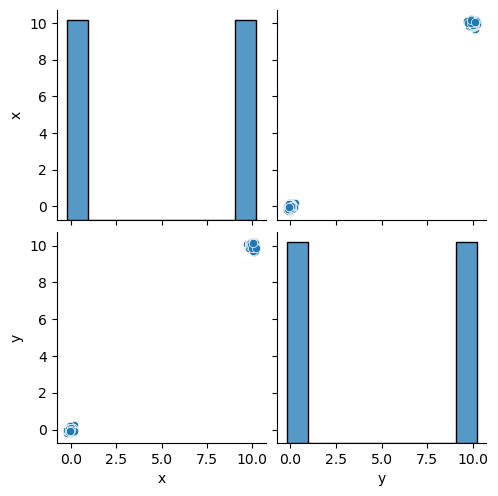

In [10]:
sns.pairplot(pd.DataFrame({"x":x,"y":y}));